In physics, how do mass matrices work? Newton's second law becomes $F = Ma$, so $a = M^{-1}F$. Suppose now we have a mass matrix in the form $(1, 0.9 | 0.9, 1)$. This means it is much harder to move the particle in the (1, 1) direction than the (1, -1) direction for example. The inverse is $(5.26, -4.74 | -4.74, 5.26)$, so therefore if we apply a 1 unit force in the $x$ direction the particle actually accelerates in the direction $$(5.26, -4.74 | -4.74, 5.26)(1, 0) = (5.26, -4.74).$$ So, the particle accelerates in the (1, -1) direction, which makes sense!

Why can't we just descend along the gradient when doing Hamiltonian Monte Carlo? If we did so, the paramatrization of the sample space would matter, so we would end up at somewhere that also depends on the parametrization of sample space: the mode. However, if we descend along the gradient while ALSO accounting for momentum, then because momentum scales inversely with position (energy is parametrization independent), we will end up somewhere that does not depend on parametrization: the typical set. 

Key point: we want uniform and regular energy level sets!

Why should the mass matrix $M$ equal the inverse of the covariance of the position? Choosing a mass matrix is like picking how distance is measured over position space: $\triangle(q_1, q_2) = (q_1 - q_2)^TM(q_1 - q_2)$. This implies a way distance is measured over momentum space (because they must scale as inverses): $\triangle(p_1, p_2) = (p_1 - p_2)^TM^{-1}(p_1 - p_2).$ So, it makes sense to let $$K(p|q) = \frac{1}{2}p^TM^{-1}p$$. Now, if we make the substitutions $p' = \sqrt(M^{-1})p$ and $q' = \sqrt{M}q$, we get $$K(p'|q') = \frac{1}{2}p'^Tp'$$

implying the random "bursts" of momentum that we add are distributed according to a unit Gaussian. These substituions also imply that $$V(q') = \frac{1}{2}(q')^T\sqrt(M^{-1})\Sigma^{-1}\sqrt(M^{-1})q'$$

So, thinking in terms of $p'$ and $q'$, the choice of $M$ does indeed transform the shape of the "bowl" $V(q')$. To get the bowl to look as nice as possible, we let $M = \Sigma^{-1}$. Then, $V(q') = \frac{1}{2}(q')^Tq'$, and the energy level sets will be very regular. 

(How do we estimate $\sigma$ in the first place? We use a "dummy"/"default" sigma initially to get a rough estimate, then use the rough estimate to get a better one, and so on...)

Notes on choosing an integration time: We want to be able to make one orbit around an energy level set; as that allows us to fully explore it. However, if we do more than one orbit we are wasting time (as the mean of the point we choose converges to the mean of the orbit very slowly)

Key equation: If $K(p|q) = |p|$ and $V(q) = |q|^{\beta}$, then the optimal integration time is given by $$T(p, q) \alpha (H(p, q))^{\frac{2 - \beta}{\beta}}$$. So, when there are heavy tails on the position distribution, we want to integrate for longer. In practice, this means that the optimal integration time depends on the local geoemtry of positon space. Two resolutions:

-No U Turn criterion

-Exhaustive Termination Criteria

Notes on integrating Hamilton's Equations:

We usually need symplectic integrators; those are good because they preserve volume in phase space. One example, the Leapfrog Integrator:

$$p_{n + 0.5} = p_n -\frac{\epsilon}{2} \frac{\partial V}{\partial Q} (q_n)$$
$$p_{n + 1} = q_n + \epsilon \frac{\partial K}{\partial p}(p_{n + 0.5})$$
$$p_{n + 1} = p_{n + 0.5} -\frac{\epsilon}{2} \frac{\partial V}{\partial Q} (q_{n + 1})$$

However, an issue is that if phase space is highly curved, sympletic integrators can at times fail epically (diverge super quickly). These fails are easier to catch than the slower drift of other generic integrators though. 

Notes on doing HMC in practice:

-Choosing a step size and number of integration steps are very important. "Trial" runs should be used, and trace/autocorrelation plots should be analyzed. Also, doing different runs with different random starting states is good to detect multiple mode issues

 -The step size $\epsilon$:
 
 There is a "stability limit" on $\epsilon$ that is, assuming the momentum distrubiton is a unit Gaussian, roughly the smallest "width" of the position distribution. In other words, assuming a Gaussian distribution, it is the square root of its smallest eigenvalue. If the momentum distribution is not a unit Gaussian, we must make the substitutions make the substitutions $p' = \sqrt(M^{-1})p$ and $q' = \sqrt{M}q$ (equivalently $q' = L^{-1}q$ where $LL^T = M^{-1}$ ideally also being equal to $\Sigma$ the position covariance) before analyzing the eigenvalues of the position distribution. \\

 Low dimensions: it is OK to make the step size just a little below this limit. High dimensions: the step size may need to be more significantly below the limit.

 Issue: in a complex posterior distribution, the stability limit can be very different in different areas of the distrubiton. For example, it could be quite low in a Gaussan with small tails. Randomly choosing $\epsilon$ each HMC integration is a solution here, as even if some $\epsilon$ values will be too big others will be just right.

 -The trajectory length $L$: 
 
 We want to explore each energy level set enough but not too much (we don't want to fully or almost fully traverse it, and we also don't want to have periodicity issues). Because a posterior probability distrubiton could be very complicated, $L$ is best determined with trial and error. $L = 100$ is a good starting point for complicated problems.

 -Instead of rescaling, to deal with different scales in different position variables, we can vary the leapfrog step sizes for each invidual value. Specifically, if $s_i$ is a scale for $q_i$, we let $p_i' = s_ip_i$ and introduce a new stepsize $\epsilon_i = s_i\epsilon$

 -HMC can also be combined with other $MCMC$ updates, as long as the other updates preserve the probability distrubtion in phase space. It is OK to add more variables as long as the entire probability distrubiton is held constant and position and momentum can just be marginalized out (?)

 -How to deal with mutliple different modes? Tempering. During each HMC transition, multiply the momentum by $\sqrt{\alpha}$ in the first momentum update for the first half of the leapfrog steps, and then divide the momentum by $\sqrt{\alpha}$ in the second momentum update for the second half of the leapfrog steps. 


In [ ]:
def KL_div_between_two_Gaussians(x1, cov1, x2, cov2, num_dimensions):
    _, logabsdet1 = jnp.linalg.slogdet(cov1)
    _, logabsdet2 = jnp.linalg.slogdet(cov2)
    return 0.5*( logabsdet2 - logabsdet1
               - num_dimensions
                + jnp.linalg.trace(jnp.linalg.solve(cov2, cov1))
                + (x2 - x1).T @ jnp.linalg.solve(cov2, x2 - x1))

Task 7/8: Try to write out what formulas HMC will allow us to calculate 

$$P(\xi | d) = P(d | \xi)P(\xi)/P(d)$$

With HMC, we are able to take samples $\xi$ from the posterior. So, $\int f(\xi)P(\xi | d)d\xi$, the expected value of a function $f$ under the posterior, is roughly $(\sum f(\xi_{\text{sample}}))/N_{\text{samples}}$

Notes on generating GPs using harmonic transforms: 

We can use the following formula. $\tilde{S}$ is the covariance matrix of the GP in harmonic space (I think harmonic space means that each entry is the "amplitude of a certain frequency" somehow?) The Wiener Khinchin Theorem says that $\tilde{S}$ is diagonal, meaning that the harmonic amplitudes are independent. Anyway, the formula is: 

$$s = HT\sqrt{\tilde{S}}\xi$$

We want to use the Hartley Transform because it sends real values to real values and somehow is harmonic. We see that 

$$H(\omega) = \int_{-\infty}^{\infty}f(t)(\cos(\omega t) + \sin(\omega t))dt$$

Notes on the Fisher Information Metric: 

In our problem, we are trying to infer a field $\xi$, and we have some data $d$. The negative logdensity function is as follows:

$$-\log P(\xi | d) = - \log P(d | \xi) - \log P(f) = 0.5(d - R(\xi))^T \Sigma^{-1} (d - R(\xi)) - \log \text{prior}(\xi)$$

$R$ is an arbitrary response function that does NOT have to be linear!!! In the context of our problem, the Fisher Information Metric tells us how much knowing $d$ will help us infer $\xi$. Specifically, it is defined as the expected value over $d$ of the covariance of the score. The score is the gradient of the logdensity function taken with respect to $\xi$ (so the score represents how much changing $\xi$ affects the probability desity of the data $d$). The FIM is

$$E_d[  (\nabla_\xi \log P(d ; \xi))(\nabla_\xi \log P(d ; \xi))^T  | \xi ]   $$

Equivalently, the FIM is the expected value of the Hessian of the negative logdensity with respect to $\xi$:

$$E_d[ \nabla^2_{\xi} ( -\log P(d ; \xi))]$$

Given our formula for the negative logdensity, we can compute (either way) that the FIM becomes

$$D_R(x)^T \Sigma^{-1} D_R(x) + \nabla^2_{\xi} (-\log \text{prior}(\xi))$$

where $D_R(x)$ is the Jacobian of $R$ evaluated at $x$. The left term is guaranteed to be positive semidefinite, and IF WE HAVE GAUSSIAN PRIORS then the right term is positive definite, so the overall sum will be positive definite.

Some intuition: If, at a certain value of $\xi$, changing $\xi$ in a direction $v$ does not really affect the distribution of what the data could be, the score along that direction is small. So, data samples can't tell $\xi$ from $\xi + cv$ apart, and thus, $\xi$ is not constrained in the direction $v$.

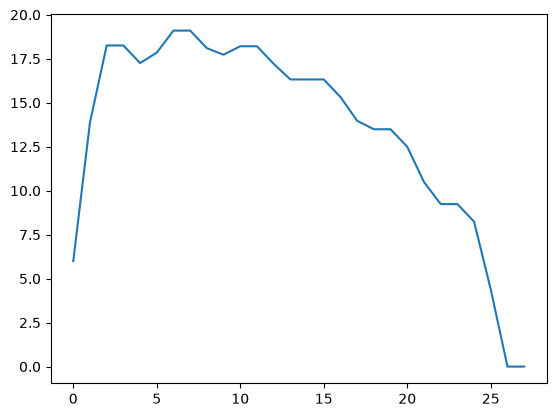

In [21]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
def hartley(x):
    X = jnp.fft.fft(x)
    return jnp.real(X) - jnp.imag(X)

linspace = jnp.arange(28)
x = jnp.array([0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])
plt.plot(linspace, jnp.cumsum(hartley(x)))
